----
# **<span style="color:SEAGREEN">PROYECTO MACHINE LEARNING ESTUDIANTES</span>**
# **<span style="color:SEAGREEN">Análisis exploratorio</span>**
----

---
---
## <span style="color:gray">**Importación de librerías**</span> 📂

In [4]:
# Tratamiento de los datos
import numpy as np
import pandas as pd

# Visualizaciones de los datos
import matplotlib.pyplot as plt
import seaborn as sns

---
---
## <span style="color:gray">**Carga de datos**</span> 📥

In [5]:
# Configuración de Pandas
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None)  # Para visualizar todas las columnas de los DataFrames

In [6]:
df = pd.read_csv("../data/raw/dataset_estudiantes.csv")

In [7]:
df.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1


---
---
## <span style="color:gray">**Análisis exploratorio**</span> 🔎

---

### 📏 Dimensión del DataFrame

In [8]:
print(f'Número de filas del DataFrame: {df.shape[0]}')
print(f'Número de columnas del DataFrame: {df.shape[1]}')

Número de filas del DataFrame: 1000
Número de columnas del DataFrame: 11


---

### 🏷️ Nombres de las columnas

In [9]:
df.columns

Index(['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia',
       'horas_sueno', 'edad', 'nivel_dificultad', 'tiene_tutor',
       'horario_estudio_preferido', 'estilo_aprendizaje', 'nota_final',
       'aprobado'],
      dtype='str')

Descripción de las columnas

- **`horas_estudio_semanal`**: Número de horas de estudio a la semana.

- **`nota_anterior`**: Nota que obtuvo el alumno en la convocatoria anterior.

- **`tasa_asistencia`**: Tasa de asistencia a clase en porcentaje.

- **`horas_sueno`**: Promedio de horas que duerme el alumno al día.

- **`edad`**: Edad del alumno.

- **`nivel_dificultad`**: Dificultad del alumno para el estudio.

- **`tiene_tutor`**: Indica si el alumno tiene tutor o no.

- **`horario_estudio_preferido`**: Horario de estudio preferido por el alumno.

- **`estilo_aprendizaje`**: Forma de estudio que emplea el alumno.

- **`nota_final`**: Nota final obtenida por el alumno, expresada en una escala de 0 a 100.

- **`aprobado`**: Indica si el alumno ha aprobado o no. Toma el valor 1 si la nota final es ≥ 60 y 0 si la nota final es < 60. 

---

### 🧾 Información general

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   horas_estudio_semanal      1000 non-null   float64
 1   nota_anterior              1000 non-null   float64
 2   tasa_asistencia            1000 non-null   float64
 3   horas_sueno                850 non-null    float64
 4   edad                       1000 non-null   int64  
 5   nivel_dificultad           1000 non-null   str    
 6   tiene_tutor                1000 non-null   str    
 7   horario_estudio_preferido  900 non-null    str    
 8   estilo_aprendizaje         950 non-null    str    
 9   nota_final                 1000 non-null   float64
 10  aprobado                   1000 non-null   int64  
dtypes: float64(5), int64(2), str(4)
memory usage: 86.1 KB


---

### 🔁 Identificación de duplicados

In [11]:
print(f'El número de duplicados del dataset es: {df.duplicated().sum()}')

El número de duplicados del dataset es: 0


---

### ❌ Detección de nulos

In [12]:
nulos = df.isnull().sum()
if nulos.any() > 0:
        print(f"El número de valores nulos de cada columna es: \n\n{nulos[nulos > 0]}\n")    
else:
        print('No hay nulos')

nulos_porcentaje = df.isnull().sum() / (df.shape[0])*100
if nulos_porcentaje.any() > 0:
        print(f"El porcentaje de valores nulos de cada columna es: \n\n{nulos_porcentaje[nulos_porcentaje > 0].round(4)}")
else:
       pass

El número de valores nulos de cada columna es: 

horas_sueno                  150
horario_estudio_preferido    100
estilo_aprendizaje            50
dtype: int64

El porcentaje de valores nulos de cada columna es: 

horas_sueno                  15.0
horario_estudio_preferido    10.0
estilo_aprendizaje            5.0
dtype: float64


---

### 🔣 Identificar variables numéricas y variables categóricas

In [13]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=['str', 'category']).columns

print("Variables numéricas:\n\n", num_cols)
print("\nVariables categóricas:\n\n", cat_cols)

Variables numéricas:

 Index(['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia',
       'horas_sueno', 'edad', 'nota_final', 'aprobado'],
      dtype='str')

Variables categóricas:

 Index(['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido',
       'estilo_aprendizaje'],
      dtype='str')


---

### 🔢 Variables numéricas

#### Estadísticas descriptivas

In [14]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,1000.0,10.07,4.85,1.0,6.63,10.00,13.37,25.0
nota_anterior,1000.0,69.89,14.69,30.0,59.88,70.00,80.12,100.0
tasa_asistencia,1000.0,73.99,18.20,20.0,61.51,75.00,88.49,100.0
horas_sueno,850.0,7.01,1.44,4.0,6.00,7.02,8.02,10.0
edad,1000.0,23.53,3.48,18.0,21.00,24.00,27.00,29.0
nota_final,1000.0,71.44,9.56,30.0,64.78,71.40,77.90,100.0
aprobado,1000.0,0.90,0.30,0.0,1.00,1.00,1.00,1.0


#### Visualizaciones

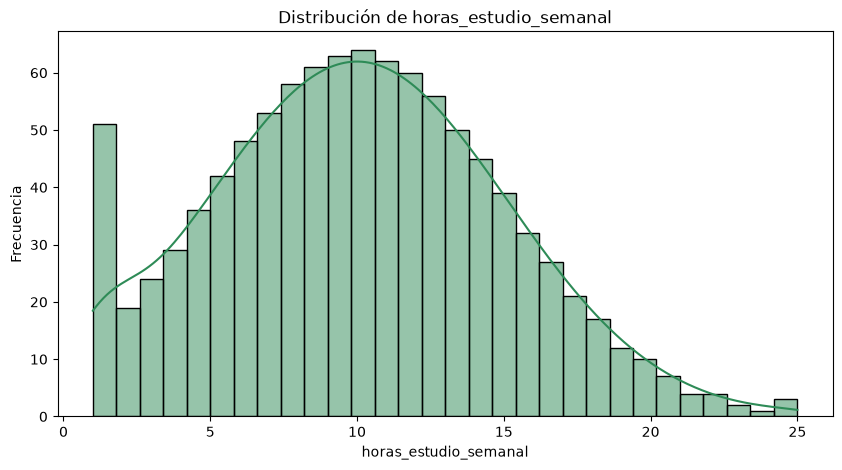

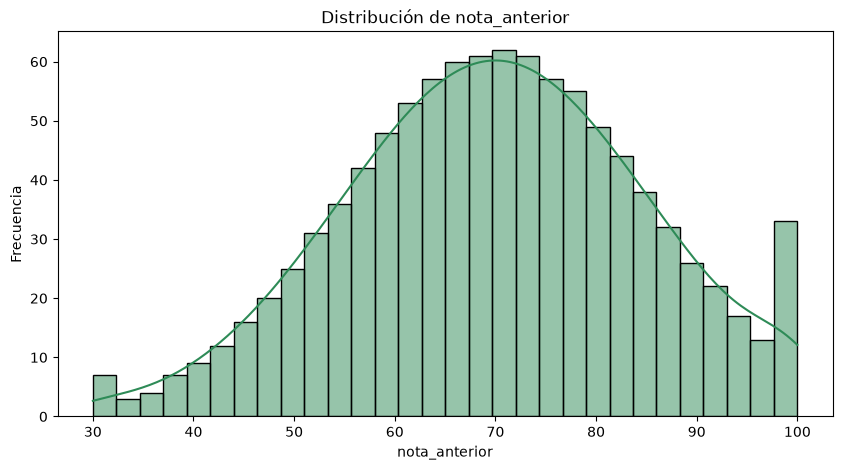

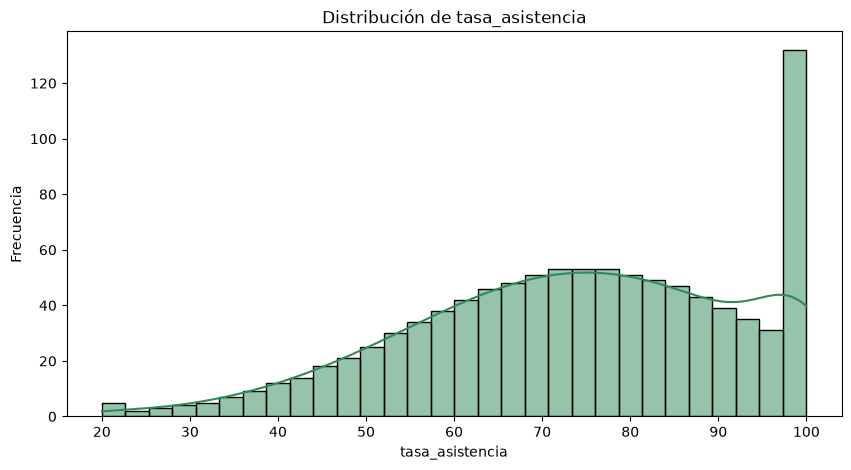

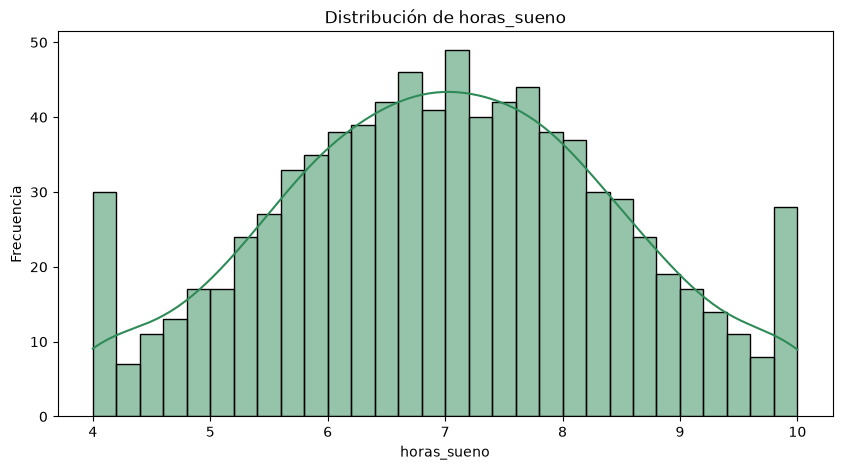

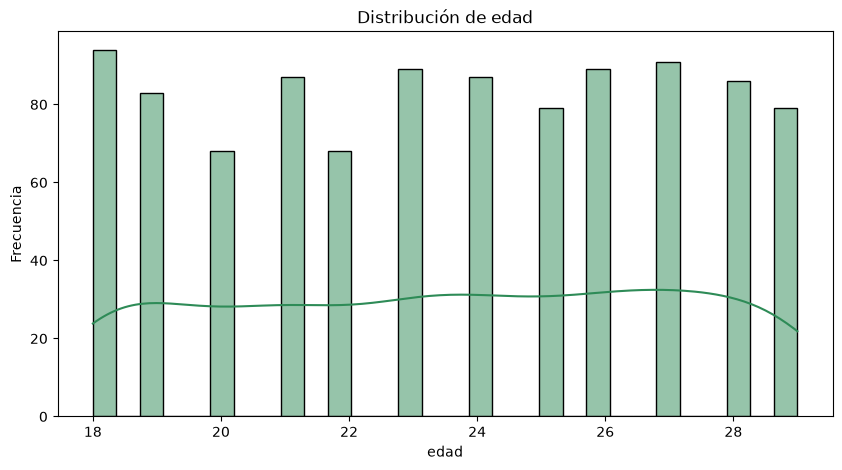

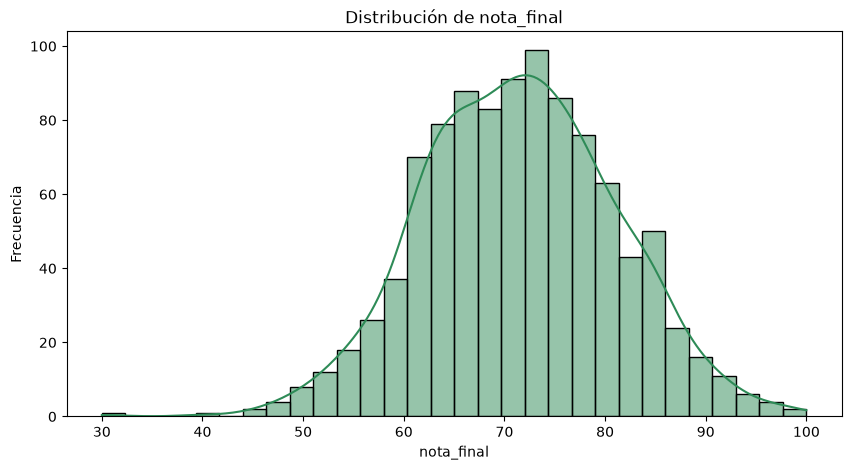

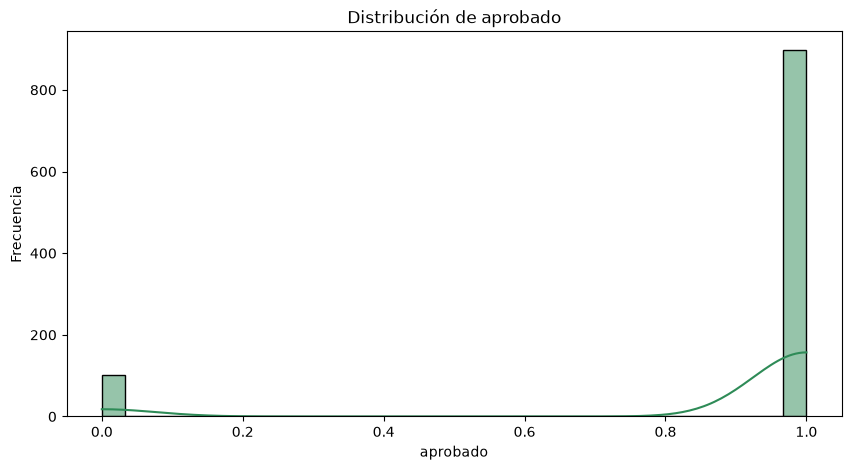

In [15]:
for col in num_cols:
    
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], bins=30, kde=True, color='seagreen', edgecolor='black')

    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

    plt.show()

#### Insights de las variables numéricas

- Las variables `horas_estudio_semanal`, `nota_anterior`, `nota_examen_final` y `horas_sueno` muestran curvas acampanadas muy claras. Esto indica que la gran mayoría de los estudiantes se concentra en torno al promedio, y los casos extremos (calificaciones muy bajas o perfectas, o dormir muy poco/demasiado) son poco comunes.

- La gráfica de `edad` muestra barras prácticamente de la misma altura en todos los rangos. Esto significa que la muestra está perfectamente balanceada y cuenta con casi la misma cantidad de estudiantes para cada edad registrada.

- El gráfico de `tasa_asistencia` presenta una marcada asimetría hacia la derecha con una barra alta en el extremo superior (cercano al 100%). La gran mayoría de los alumnos tiene una asistencia casi perfecta, habiendo muy pocos casos de ausentismo severo.

- La variable `aprobado` se comporta de forma binaria, concentrando la gran mayoría de sus datos en el valor más alto. Esto sugiere que la tasa de éxito en este grupo de estudiantes es elevada.

---

### 🔡 Variables categóricas

#### Estadísticas descriptivas

In [16]:
df.describe(include = "str").T

,count,unique,top,freq
nivel_dificultad,1000,3,Medio,504
tiene_tutor,1000,2,No,597
horario_estudio_preferido,900,3,Noche,344
estilo_aprendizaje,950,4,Visual,363


#### Valores únicos y frecuencias

In [17]:
for col in cat_cols:
    print(f" \n----------- ESTAMOS ANALIZANDO LA COLUMNA: '{col}' -----------\n")
    print(f"Valores únicos: {df[col].unique()}\n")
    print("Frecuencias de los valores únicos de las categorías:")
    display(df[col].value_counts())

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'nivel_dificultad' -----------

Valores únicos: <StringArray>
['Fácil', 'Difícil', 'Medio']
Length: 3, dtype: str

Frecuencias de los valores únicos de las categorías:


nivel_dificultad
Medio      504
Fácil      313
Difícil    183
Name: count, dtype: int64

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'tiene_tutor' -----------

Valores únicos: <StringArray>
['Sí', 'No']
Length: 2, dtype: str

Frecuencias de los valores únicos de las categorías:


tiene_tutor
No    597
Sí    403
Name: count, dtype: int64

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'horario_estudio_preferido' -----------

Valores únicos: <StringArray>
['Tarde', 'Mañana', nan, 'Noche']
Length: 4, dtype: str

Frecuencias de los valores únicos de las categorías:


horario_estudio_preferido
Noche     344
Tarde     337
Mañana    219
Name: count, dtype: int64

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'estilo_aprendizaje' -----------

Valores únicos: <StringArray>
['Lectura/Escritura', nan, 'Visual', 'Auditivo', 'Kinestésico']
Length: 5, dtype: str

Frecuencias de los valores únicos de las categorías:


estilo_aprendizaje
Visual               363
Auditivo             254
Kinestésico          178
Lectura/Escritura    155
Name: count, dtype: int64

#### Visualizaciones 

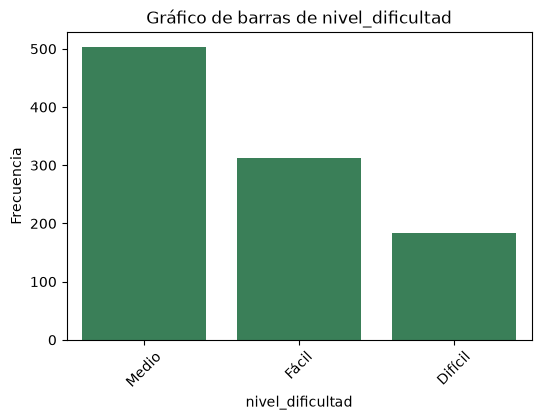

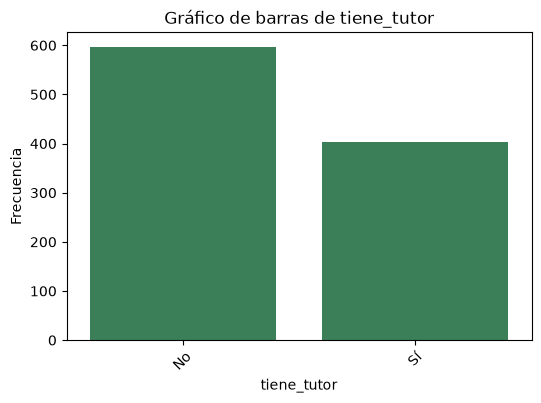

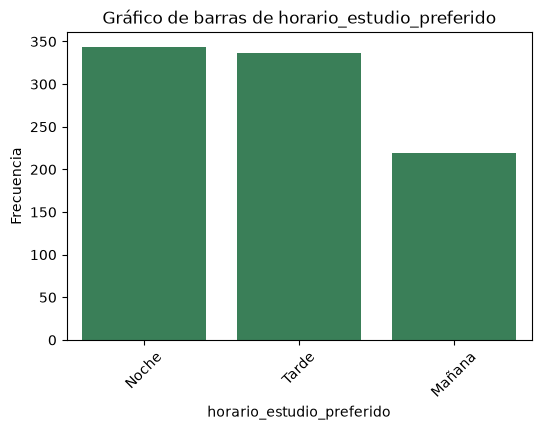

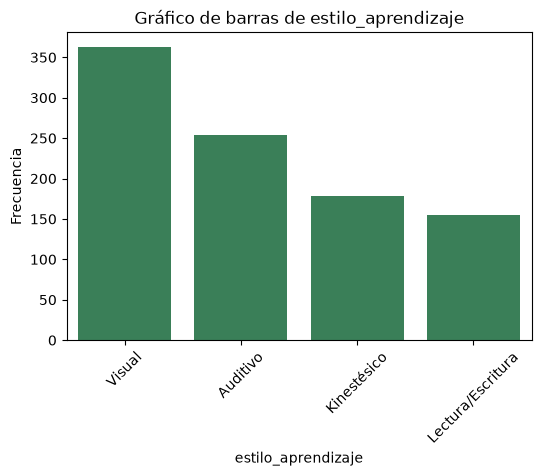

In [18]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], order=df[col].value_counts().index, color='seagreen')

    plt.title(f'Gráfico de barras de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)

    plt.show()

#### Insights de las variables categóricas

- En `nivel_dificultad`, la categoría "Medio" es la más frecuente (con 504 menciones), seguida de "Fácil" y, por último, "Difícil". Es decir, en general, los estudiantes perciben el contenido mayoritariamente como moderado.

- En la variable `tiene_tutor`, la opción "No" es la predominante (597 casos), lo que demuestra que más de la mitad de los alumnos no cuenta con un tutor académico que acompaña su proceso.

- El horario favorito para estudiar (`horario_estudio_preferido`) se concentra principalmente en la "Noche" (el valor más alto con 384 registros) y la "Tarde". La "Mañana" es la opción menos popular entre los estudiantes.

- En cuanto a la variable `estilo_aprendizaje`, el método "Visual" destaca como el líder (263 casos), seguido de cerca por el estilo "Auditivo", quedando las modalidades "Kinestésico" y "Lectura/Escritura" en los últimos lugares de preferencia.

---

### 🔗 Matriz de correlación 

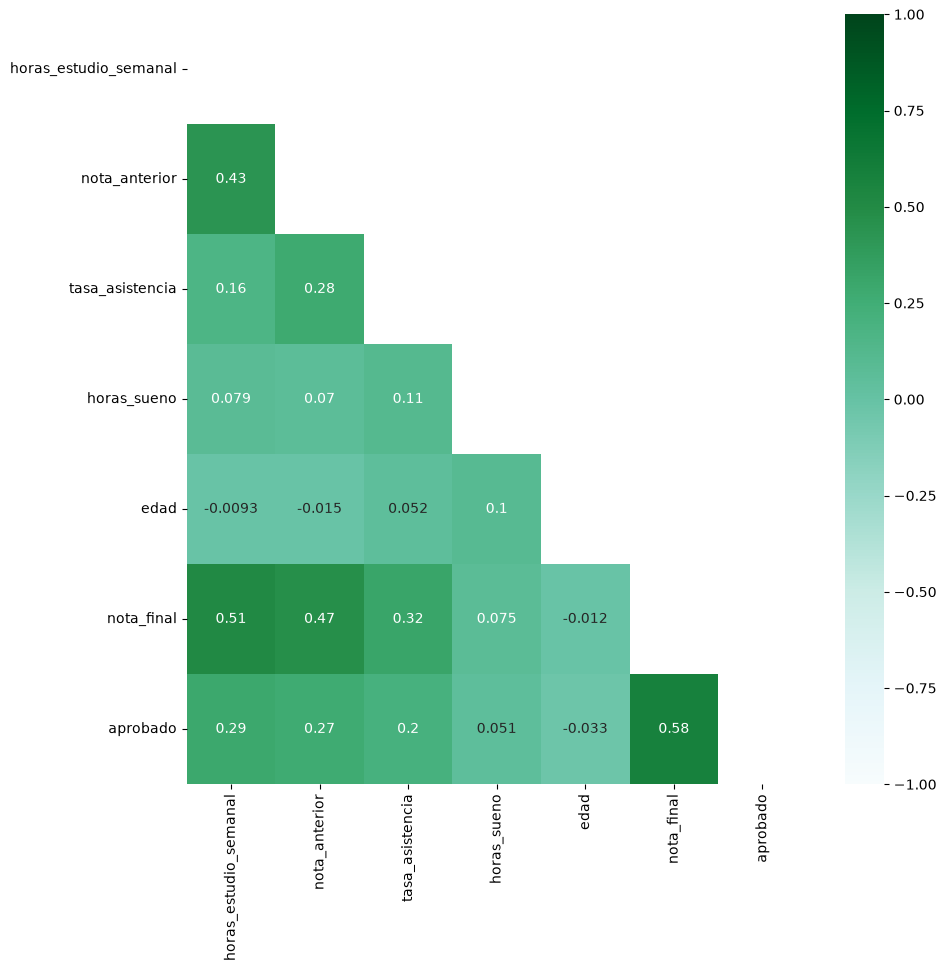

In [19]:
# Calcular la matriz de correlación
corr_matrix = df.corr(numeric_only=True)

# Crear la figura
plt.figure(figsize=(10, 10))

# Crear una máscara para mostrar solo la parte triangular
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Graficar el mapa de calor
sns.heatmap(corr_matrix, 
            annot=True, 
            vmin=-1, 
            vmax=1, 
            mask=mask,
            cmap='BuGn')

plt.show()

#### Variables Correlacionadas

- Las variables más vinculadas a `nota_final` son `horas_estudio_semanal` (0.51) y `nota_anterior` (0.47). A mayor dedicación en horas y mejor rendimiento en el pasado, más alta tiende a ser la calificación final.

- Existe una relación positiva moderada (0.32) entre `tasa_asistencia` y `nota_final`. La presencialidad o constancia en las aulas se traduce en mejores notas.

- La correlación más fuerte es entre `aprobado` y `nota_final` (0.58). Esto demuestra matemáticamente que sacar notas altas y aprobar el curso van directamente de la mano, confirmando que los datos son totalmente lógicos y coherentes.

- Hay una correlación de 0.43 entre `nota_anterior` y `las horas_estudio_semanal`. Esto sugiere que los alumnos que ya venían con buenas calificaciones previas tienden a ser los mismos que más horas le dedican al estudio actualmente.

- `tasa_asistencia` está ligeramente correlacionada (0.28) con `nota_anterior`. Los estudiantes con mejor historial académico suelen faltar menos a clase.

#### Variables Independientes

- El sueño no altera las notas: `horas_sueno` muestran coeficientes casi nulos con el rendimiento (0.075 con la nota final). En este grupo, dormir más o menos horas no parece estar asociado con sacar mejores o peores calificaciones.

- La edad es irrelevante: `edad` tiene una correlación prácticamente de cero con absolutamente todo el dataset. El comportamiento, las notas, las horas de estudio y la asistencia son homogéneos sin importar cuántos años tenga el estudiante.

---

### 🔀 Relaciones cruzadas

#### Variable objetivo numérica `nota_final`

##### Gráficos de dispersión

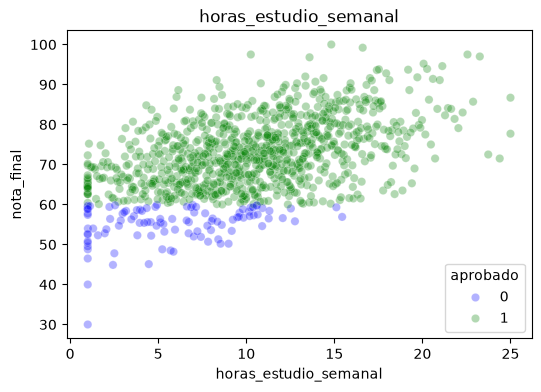

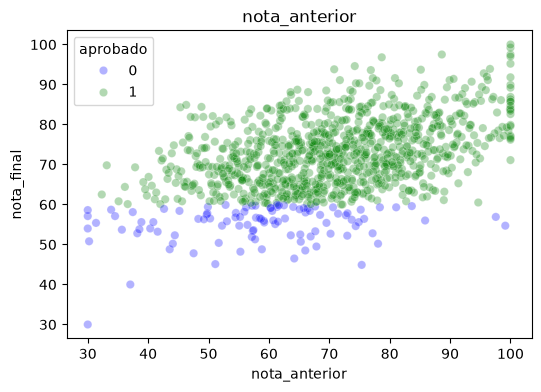

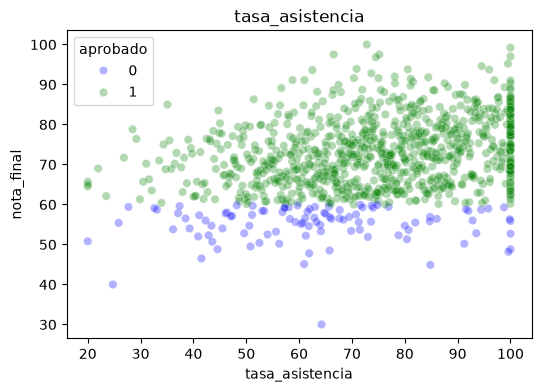

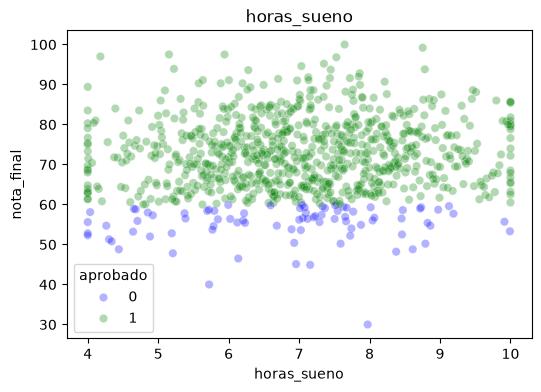

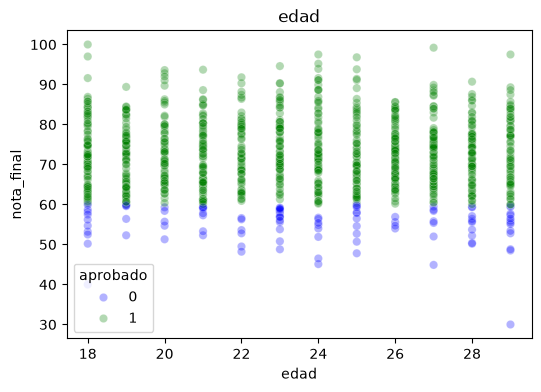

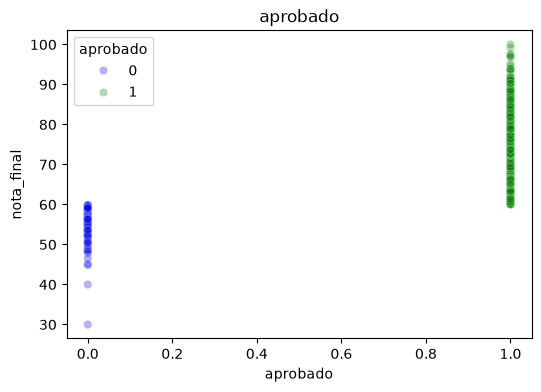

In [20]:
# Definir la variable objetivo
tv = 'nota_final'

# Definir DataFrame y variables numéricas
df_num = df.select_dtypes(include=np.number).drop(columns=[tv], errors='ignore')
cols_num = df_num.columns

# Paleta de colores
palette = {
    0: 'blue',
    1: 'green'
}

# Generar gráficos de dispersión
for col in cols_num:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df[tv], hue=df['aprobado'], palette=palette, alpha=0.3)
  
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel(tv)
    plt.show()

- Horas de estudio e historial académico: Los gráficos de dispersión de `horas_estudio_semanal` y `nota_anterior` muestran una clara tendencia ascendente que valida visualmente las correlaciones más altas (0.51 y 0.47). Se observa que los alumnos con mejores notas previas son los que más horas dedican a estudiar y, en consecuencia, logran las calificaciones finales más altas (puntos verdes arriba a la derecha).


- Asistencia y éxito escolar: El gráfico de dispersión de `tasa_asistencia` explica la concentración de datos cercana al 100% que vimos antes: existe una enorme densidad de alumnos aprobados (puntos verdes) pegados al extremo derecho. La constancia en clase aumenta la probabilidad de aprobar, mientras que el ausentismo se asocia directamente a las notas bajas.

- Variables sin impacto (Sueño y Edad): Ambos gráficos respaldan la nula correlación de la matriz. En `horas_sueno`, los datos forman una nube de puntos totalmente dispersa y sin una dirección clara, demostrando que dormir más o menos horas no altera el rendimiento en este grupo. Por su parte, el gráfico de `edad` muestra columnas uniformes de los 18 a los 29 años, donde las franjas de aprobados y no aprobados mantienen la misma proporción en todas las edades.

- El gráfico binario de `aprobado` contra `nota_final` confirma la correlación de 0.58 mediante una división horizontal perfecta por colores: la nota mínima para aprobar es 60 puntos. Por debajo de ese umbral, el 100% de los alumnos no ha superado la materia (puntos azules).

##### Boxplots

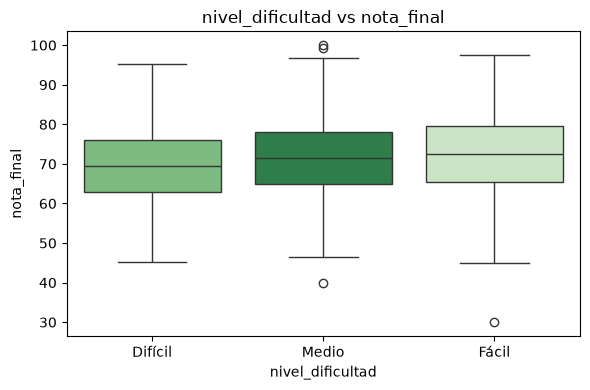

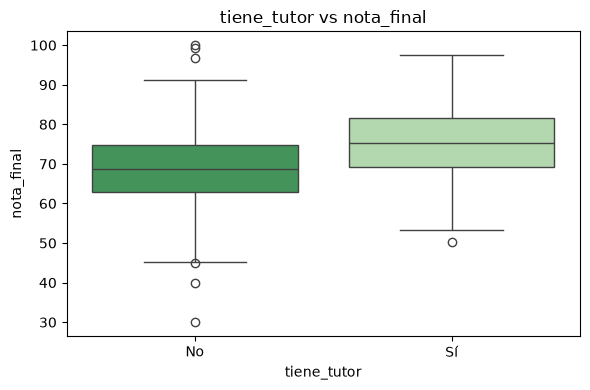

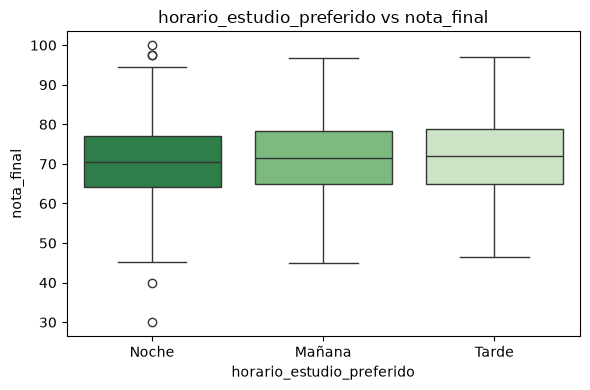

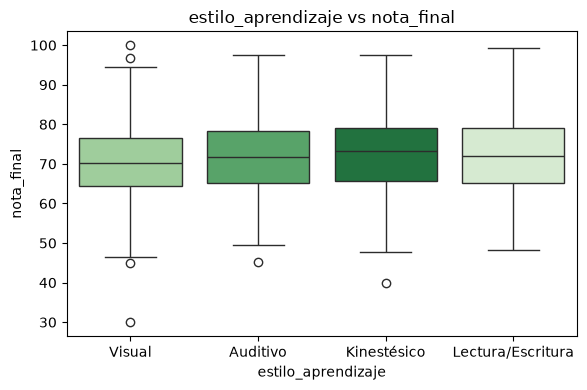

In [21]:
# Definir la variable objetivo
tv = 'nota_final'

# Generar gráficos independientes para cada variable categórica
for col in cat_cols:
    # Ordenar las categorías por el promedio de la variable objetivo
    ordered_cats = df.groupby(col)[tv].mean().sort_values().index

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], y=df[tv], hue=df[col], data=df, order=ordered_cats, palette='Greens' , legend=False)
    
    plt.title(f"{col} vs {tv}")
    plt.xlabel(col)
    plt.ylabel(tv)
    plt.tight_layout()
    plt.show()

- El gráfico de `tiene_tutor` es el que muestra la diferencia más marcada. Aunque casi el 60% de los alumnos no tiene tutor, el gráfico de cajas revela que quienes sí cuentan con este apoyo logran un rendimiento notablemente superior (su caja está desplazada hacia arriba) en comparación con quienes no lo tienen.

Casos excepcionales (outliers) en tutorías: En el grupo con tutor ("Sí"), aparecen alumnos que, a pesar del acompañamiento, obtuvieron notas inusualmente bajas (cercanas a 60). En el grupo sin tutor ("No"), destacan tanto estudiantes brillantes con notas perfectas (cercanas a 100) conseguidas de forma autónoma, como otros que cayeron a calificaciones muy bajas.

- En `nivel_dificultad`, `horario_estudio_preferido` y `estilo_aprendizaje`, las medianas de las cajas están alineadas prácticamente a la misma altura. Esto confirma que la percepción del nivel de dificultad de la materia, la hora de estudio, o tener un estilo de aprendizaje u otro no parece alterar la nota final del estudiante.

Casi todas las categorías de estas variables muestran outliers inferiores. Estos representan a alumnos específicos que tuvieron un desempeño muy bajo en comparación con el promedio del resto de sus compañeros de grupo.

#### Variable objetivo categórica `aprobado`

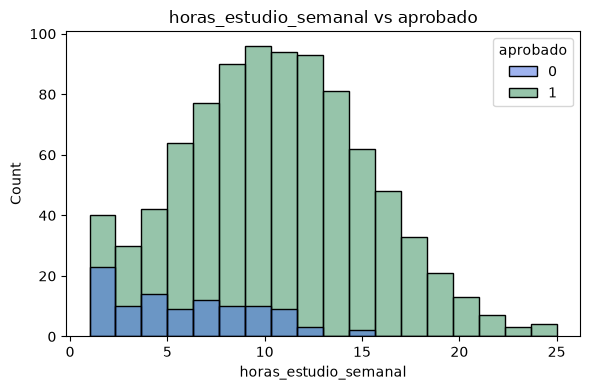

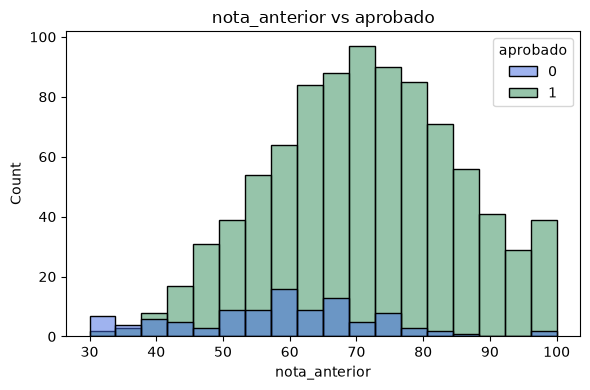

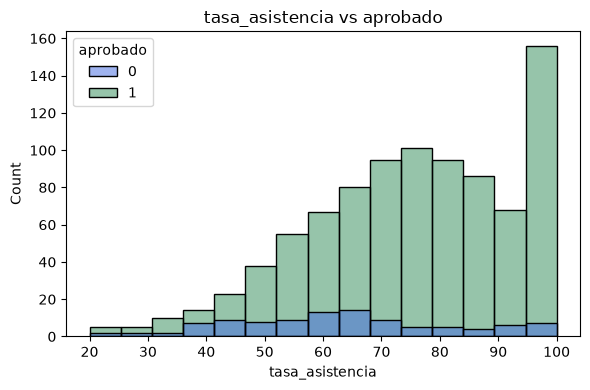

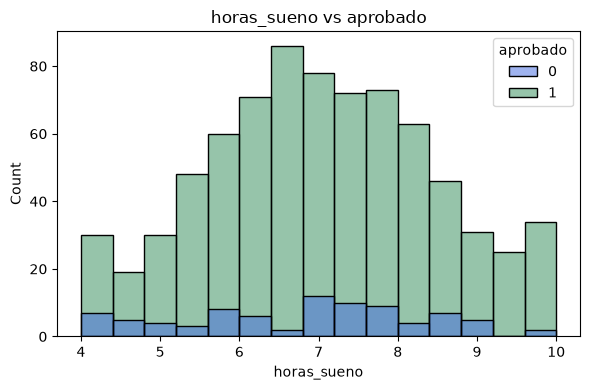

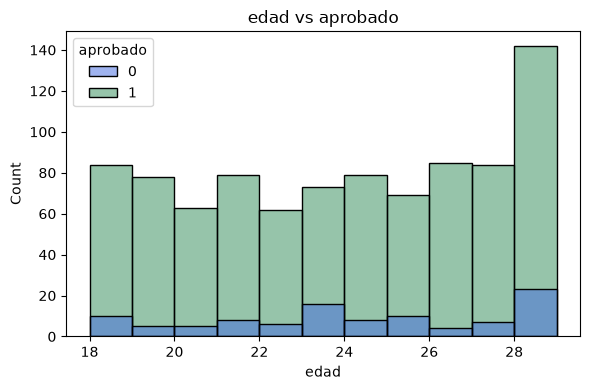

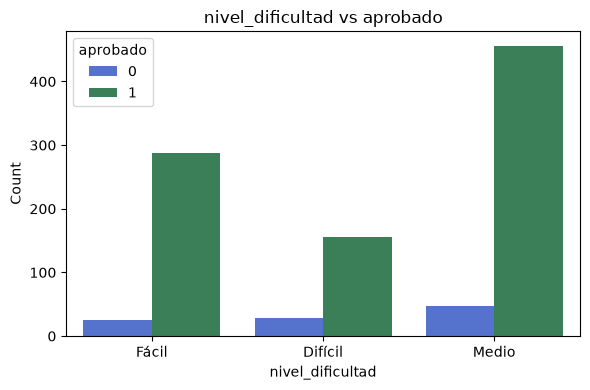

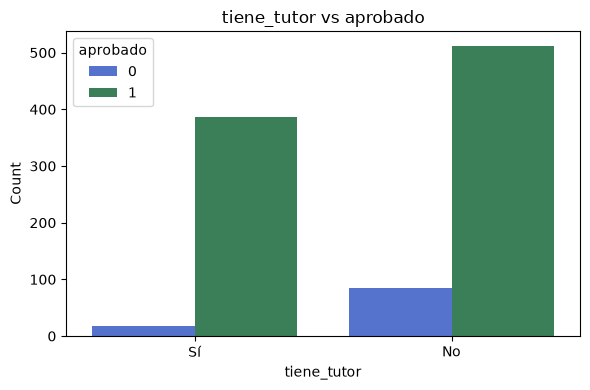

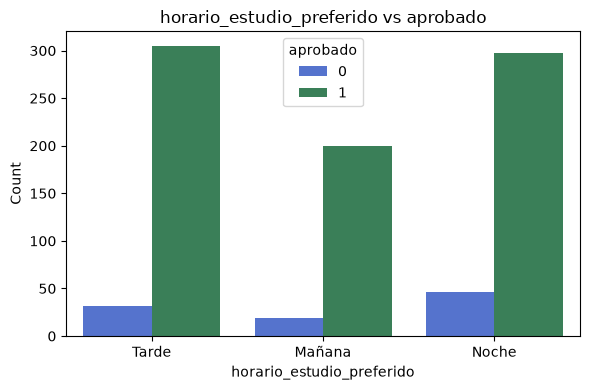

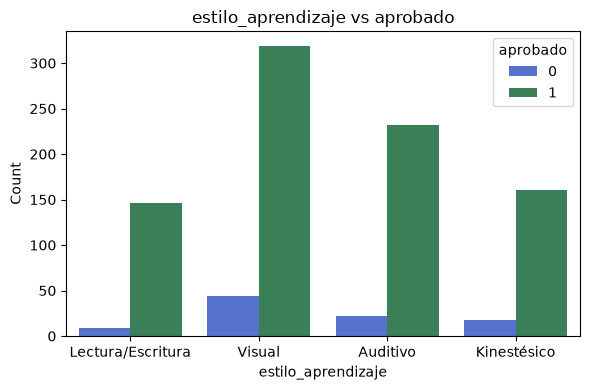

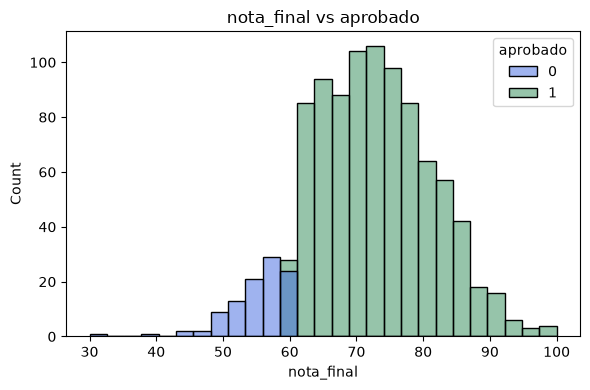

In [22]:
# Definir la variable objetivo
tv = 'aprobado'

for col in df.columns:
    # Saltar la variable objetivo
    if col == tv:
        continue

    plt.figure(figsize=(6,4))

    palette = {
    0: 'royalblue',
    1: 'seagreen'
}

    if col in num_cols:
        sns.histplot(x=df[col], hue=df[tv], data=df, palette=palette, legend=True)
    elif col in cat_cols:
        sns.countplot(x=df[col], hue=df[tv], data=df, palette=palette)

    plt.title(f"{col} vs {tv}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

#### Variables Numéricas 

- El gráfico de `horas_estudio_semanal` muestra que por debajo de las 5 horas de estudio a la semana, el riesgo de suspender es mayor (concentración del color azul). Sin embargo, a partir de las 10 horas, la probabilidad de aprobar es muy alta (la presencia del azul desaparece casi por completo), confirmando de forma visual el coeficiente de 0.51 que vimos en la matriz.

- En `nota_anterior`, el peligro se concentra en quienes traen un historial menor a 50 puntos. A partir de los 60 puntos anteriores, prácticamente todos los alumnos logran aprobar el curso.

- El gráfico de `tasa_asistencia` muestra que casi todos los aprobados (verde) se acumulan en la barra del 90% al 100% de asistencia. En cambio, aunque los alumnos que suspenden (azul) aparecen en casi cualquier nivel de asistencia, el riesgo de no pasar el curso aumenta cuando la asistencia baja del 50%.

- El histograma de `nota_final` valida perfectamente la barrera que descubrimos en el gráfico de dispersión: De 0 a 59 puntos las barras son 100% azules (suspensos) y de 60 a 100 son 100% verdes (aprobados).

- Los gráficos de `edad` y `horas_sueno` muestran que la proporción entre aprobados (verde) y suspensos (azul) es casi idéntica en todas las barras. Esto demuestra que la probabilidad de aprobar o suspender es la misma sin importar la edad del estudiante o las horas que duerma.

#### Variables Categóricas

- Aunque la mayoría de los alumnos percibe la materia con un nivel de dificultad "Medio", el mayor volumen de alumnos suspensos (barra azul más alta) se concentra en esa categoría. 

- El gráfico de `tiene_tutor` expone que la mayoría de los suspensos pertenece al grupo que NO tiene tutor. El grupo que sí tiene tutor registra un índice de suspenso prácticamente nulo, consolidando lo que vimos en el gráfico de cajas: tener tutor marca una gran diferencia.

- En `horario_estudio_preferido` y `estilo_aprendizaje`, la porción de alumnos que suspenden (azul) se reparte de forma muy equilibrada entre todas las barras. Esto demuestra que estudiar de noche, por la tarde, o tener un método visual o auditivo no influye en las posibilidades de superar la materia.

---

### ⚠️ Inconsistencias

#### Comprobamos valores mínimos y máximos de las columnas numéricas

In [23]:
# Valores mínimos y máximos
df[num_cols].agg(['min', 'max']).T

,min,max
horas_estudio_semanal,1.0,25.0
nota_anterior,30.0,100.0
tasa_asistencia,20.0,100.0
horas_sueno,4.0,10.0
edad,18.0,29.0
nota_final,30.0,100.0
aprobado,0.0,1.0


#### Coherencia entre `nota_final` y `aprobado`

In [24]:
inconsistencias = df[((df['nota_final'] >= 60) & (df['aprobado'] != 1)) |
                     ((df['nota_final'] < 60) & (df['aprobado'] != 0))]

if inconsistencias.empty:
    print("Las columnas son coherentes entre sí.")
else:
    print("Se han detectado inconsistencias entre las columnas.")

Las columnas son coherentes entre sí.


#### Resultado inconsistencias

Se demuestra que no existen errores lógicos ni contradicciones en el dataset; el 100% de los alumnos con 60 puntos o más están marcados como aprobados (1), y todos los que tienen menos de 60 aparecen como suspendidos (0). 

---
---

## <span style="color:gray">**Conclusiones del análisis exploratorio**</span> 📌


El análisis exploratorio muestra que el dataset está compuesto por 1.000 registros y 11 variables, sin registros duplicados y con rangos de valores coherentes para las variables analizadas.

Se han identificado valores faltantes en `horas_sueno`, `horario_estudio_preferido` y `estilo_aprendizaje`, por lo que será necesario establecer una estrategia para su tratamiento antes de entrenar los modelos. 

El análisis de las variables numéricas y categóricas permite observar diferentes patrones de distribución y posibles asociaciones con la `nota_final`. Las relaciones cruzadas y los gráficos realizados muestran que algunas variables presentan diferencias en la distribución de las notas según sus valores o categorías, aunque estas asociaciones no implican necesariamente una relación causal. Las variables con un vínculo lineal más fuerte corresponden a `horas_estudio_semanal` y `nota_anterior`, seguidas por la `tasa_asistencia`. Al cruzar los datos, se identifican fronteras de rendimiento claras: el riesgo de suspender se concentra por debajo de las 5 horas de estudio, los 50 puntos en la nota previa y el 50% de asistencia. 

En el ámbito cualitativo, disponer de un tutor académico se asocia con un rendimiento notablemente superior, mientras que las variables de `edad`, `horas_sueno`, `horario_estudio_preferido` y `estilo_aprendizaje` no muestran variaciones significativas en la calificación definitiva, mostrando comportamientos homogéneos y la presencia de algunos valores atípicos inferiores en sus categorías.

La validación lógica confirma que la variable `aprobado` está directamente definida a partir de `nota_final`, por lo que deberá tenerse en cuenta esta relación durante el modelado para evitar problemas de fuga de información (data leakage). En el caso de un modelo de clasificación cuyo objetivo sea predecir aprobado, `nota_final` no deberá utilizarse como variable predictora.

En conjunto, el análisis exploratorio permite identificar las principales características y posibles variables relevantes del dataset, proporcionando una base para la siguiente fase: el tratamiento de los datos y la construcción y evaluación de los modelos de Machine Learning.

---
---